# Get Sonoptix Images

In [1]:
import numpy as np, cv2
import matplotlib.pyplot as plt
from tools.tools import *

%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_video.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_12-10_16_52"

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Read Data

In [2]:
real_sonoptix_data = get_sonoptix_data(REAL_BAG_PATH)
simulated_sonoptix_data = get_simulated_image_data(bag=SIM_BAG_PATH, topic="/multibeam_sonar/image")

# Display Sonoptix Data

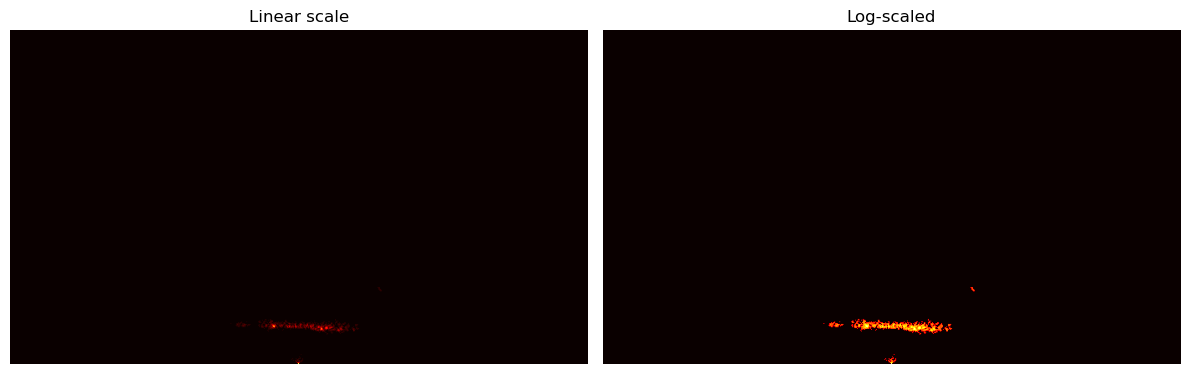

In [3]:
image = get_image_nearest_time(real_sonoptix_data, 50)

# Clip
image = image[:400, :]

# Map to polar
image = map_to_sector(image, fov_deg=120)

# Normalize intenisty values 0 to 255
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

# Flip
image = np.flipud(image) 
image = np.fliplr(image)

# Log transform
log_image = np.log(image + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap="hot")
axes[0].set_title("Linear scale")
axes[0].axis("off")

axes[1].imshow(log_image, cmap="hot")
axes[1].set_title("Log-scaled")
axes[1].axis("off")

plt.tight_layout()

# Plot ROS2 Simulated

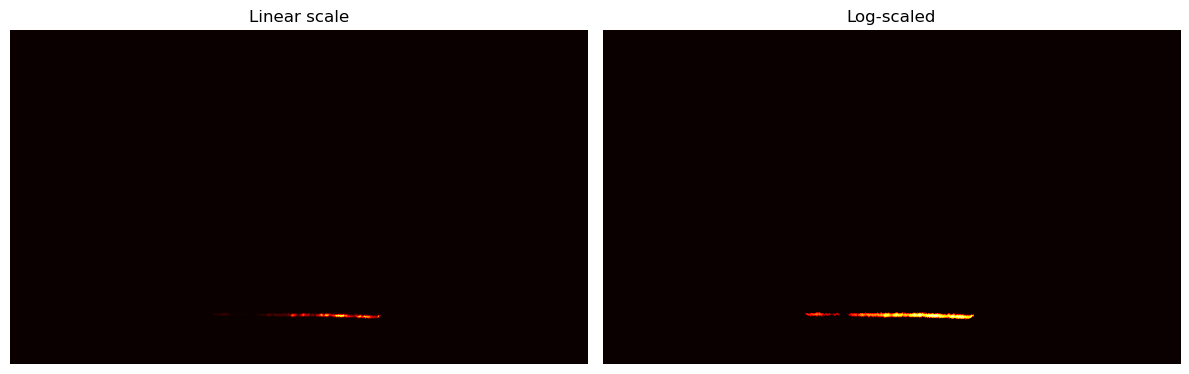

In [4]:
image = get_image_nearest_time(simulated_sonoptix_data, 50)

# Crop
image = image[(1024-400):, :]

# Map to sector
image = np.rot90(image, k=2)
image = map_to_sector(image, fov_deg=120)
image = np.rot90(image, k=2)


# Normalize intenisty values 0 to 255
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)


# Log transform
log_image = np.log(image + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap="hot")
axes[0].set_title("Linear scale")
axes[0].axis("off")

axes[1].imshow(log_image, cmap="hot")
axes[1].set_title("Log-scaled")
axes[1].axis("off")

plt.tight_layout()

# plt.figure(figsize=(10, 10))
# plt.title("Simulated Sonoptix ECHO")
# plt.imshow(image, cmap="hot")